In [1]:
import scarf

scarf.set_verbosity('WARNING')

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_5K_pbmc_rnaseq',
    zarr=True,
    destination='scarf_datasets'
)

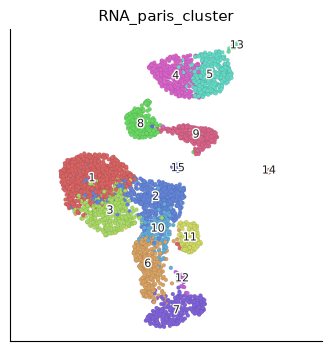

In [3]:
ds = scarf.DataStore(f'{dataset}/data.zarr')

ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_paris_clustering(n_clusters=15)

ds.run_umap(n_epochs=250, parallel=True)

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
)

In [4]:
ds.run_topacedo_sampler(
    cluster_key='RNA_paris_cluster',
    max_sampling_rate=0.1
)
if 'RNA_sketched' not in ds.cells.columns:
    raise RuntimeError(
        "TopACeDo did not create RNA_sketched. Verify that topacedo is installed."
    )

print('Active cells:', int(ds.cells.fetch_all('I').sum()))
print('Selected cells:', int(ds.cells.fetch_all('RNA_sketched').sum()))

Constructing graph from dendrogram:   0%|          | 0/3939 [00:00<?, ?it/s]

Constructing graph from dendrogram: 100%|██████████| 3939/3939 [00:00<00:00, 235179.55it/s]

INFO: 375 cells (9.52%) sub-sampled. Subsample to Seed (159 cells) ratio: 2.358


Active cells: 3940
Selected cells: 375


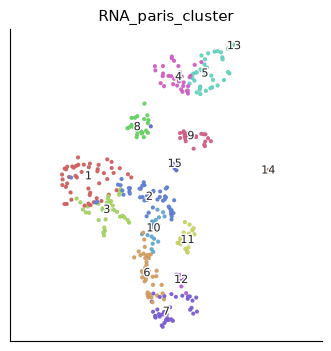

In [5]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
    subset_by='RNA_sketched',
)

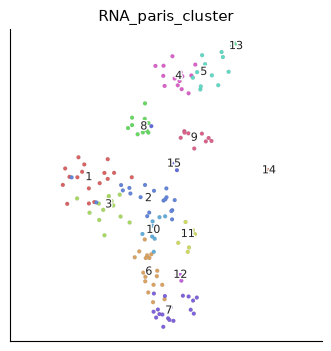

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
    subset_by='RNA_sketch_seeds',
)

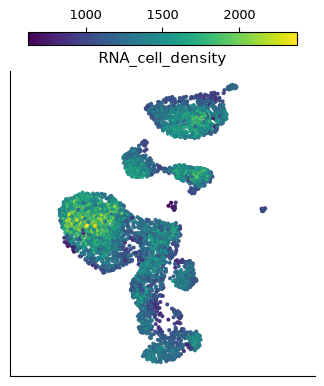

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cell_density',
)

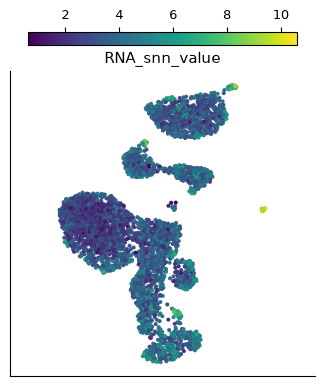

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_snn_value',
)

In [9]:
subset_path = f'{dataset}/subset.zarr'
writer = scarf.SubsetZarr(
    zarr_loc=subset_path,
    assays=[ds.RNA],
    cell_key='RNA_sketched',
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

In [10]:
ds2 = scarf.DataStore(subset_path)

ds2

DataStore has 375 (375) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentRibo', 'RNA_tSNE2', 
            'RNA_sketch_seeds', 'RNA_percentMito', 'RNA_snn_value', 'RNA_paris_cluster', 'RNA_nFeatures', 
            'RNA_cell_density', 'RNA_tSNE1', 'RNA_leiden_cluster', 'RNA_UMAP2', 'RNA_cluster', 
            'RNA_sketched', 'RNA_UMAP1', 'RNA_nCounts'
   RNA assay has 8701 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

In [11]:
adata = ds2.to_anndata()

adata

AnnData object with n_obs × n_vars = 375 × 33538
    obs: 'I', 'names', 'RNA_cell_density', 'RNA_sketch_seeds', 'RNA_percentRibo', 'RNA_tSNE1', 'RNA_percentMito', 'RNA_paris_cluster', 'RNA_snn_value', 'RNA_tSNE2', 'RNA_UMAP2', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_cluster', 'RNA_sketched', 'RNA_leiden_cluster', 'RNA_UMAP1'
    var: 'I', 'names', 'nCells', 'dropOuts'